# The execution interface: sampling and readouts


<div class="note"><span class="note-t">TL;DR</span>
<p>We show Torx readouts in practice with a two-pbit circuit, turning raw samples into histograms, expectations, and Monte Carlo error bars using ordinary array reductions. Both readouts converge at the expected 1/sqrt(N) rate.</p>
</div>

In this tutorial, we sample a small Torx circuit and turn its terminal bitstrings into readouts.

An **expectation readout** is an expectation over samples. Here it reduces the terminal bitstrings to a density or a mean. The Monte Carlo error bars shown later are diagnostics over those estimators (their uncertainty), not expectation readouts themselves.

The code uses Torx, JAX, NumPy, and Matplotlib. It assumes basic familiarity with probability distributions and expectations.

The `samples` array is the full stochastic output of `SampleSimulator.sample`: a `(num_samples, num_pbits)` integer array. Histograms, sample means, and confidence summaries are standard NumPy reductions over the rows of `samples`.

By the end, you can:

- build a two-pbit readout circuit,
- compare an exact `StateVectorSimulator` density with reductions of `samples`,
- plot histogram concentration toward the exact density, and
- estimate the Monte Carlo rate $1/\sqrt{N}$ from a block analysis.

We first build the circuit and compute the exact reference. Then we sample the circuit, compare two readout paths, and measure how the sampling error shrinks with $N$.



## Setup

We import the simulators, plotting helpers, and small utilities used by the examples.

In [1]:
from pathlib import Path
import sys

import jax
import jax.numpy as jnp
import numpy as np

from torx.psc import (
    DiscretePCircuit,
    PCNOT,
    PNOT,
    SampleSimulator,
    StateVectorSimulator,
)

We put the repository helper directory on the import path before importing the notebook-local helpers.

In [2]:
ROOT = Path.cwd()
if not (ROOT / "helpers").exists() and (ROOT.parent / "helpers").exists():
    ROOT = ROOT.parent
HELPER_DIR = ROOT / "helpers"
sys.path.insert(0, str(HELPER_DIR))

Next we import the notebook-local helpers and apply the notebook plotting style.

In [3]:
import _plots_sampling as P_samp
import _plots_schematics as P_sch
from jax.scipy.special import logit
from _notebook_paths import figure_dir
from _notebook_style import apply_notebook_style, make_savefig

FIGURE_DIR = figure_dir(ROOT)
SEED = 17

# Keep generated figures consistent with the rest of the gallery.
apply_notebook_style()
savefig = make_savefig(FIGURE_DIR)

`logit` (from `jax.scipy.special`) turns a probability into the log-odds a gate expects, and a small local helper `empirical_two_pbit_density` reduces a batch of samples to a four-state density.

In [4]:
def empirical_two_pbit_density(samples_2d):
    # Encode two bits as 00, 01, 10, 11 before counting frequencies.
    ids = samples_2d[:, 0] * 2 + samples_2d[:, 1]
    return np.bincount(ids, minlength=4) / len(samples_2d)

## The readout as an expectation

A Torx circuit is a **stochastic kernel** $K$ (a map that turns one probability distribution into another) acting on the input distribution.

The output distribution is

$$\rho_{\text{out}} = K\,\rho_{\text{in}},$$

and any readout is an expectation against $\rho_{\text{out}}$:

$$\langle f, \rho \rangle = \sum_{a} f(a)\,\rho_a.$$

A ket like $|a)$ (or $|00)$ below) labels one basis configuration of the sites, and $\rho_a$ is its probability. The bracket $\langle f, \rho \rangle$ reads off the expectation of the readout $f$ against the distribution $\rho$.

The `StateVectorSimulator` returns the exact $\rho_{\text{out}}$. The `SampleSimulator.sample` method draws $N$ bitstrings $s_n \sim \rho_{\text{out}}$, and the corresponding estimator averages $f$ over them:

$$\widehat{\langle f \rangle}_N = \underbrace{\frac{1}{N} \sum_{n=1}^{N}}_{\vphantom{\big|}\text{sample average}} f(s_n).$$

The sum runs over the $N$ drawn bitstrings, and $f(s_n)$ is the readout evaluated on each one. If $f$ is the indicator of a basis state, the estimator gives the empirical density $\hat\rho_N$.

If $f(s) = s_i$, the estimator gives the per-pbit expectation returned by `expval_all`.

Both estimators concentrate at the Monte Carlo rate. The **total-variation distance** between the empirical and exact densities scales as $\mathrm{TV}(\hat\rho_N, \rho) = O(N^{-1/2})$. A two-pbit circuit keeps the exact $\rho$ cheap to enumerate, so we can compare every estimate with a ground-truth reference.

## The smallest readout

A two-pbit circuit is large enough to show all four basis states and small enough to enumerate exactly.

The circuit contains a `PNOT` on pbit 0 with flip probability 0.38, a `PCNOT` with conditional flip probability 0.70 from pbit 0 to pbit 1, and a `PNOT` on pbit 1 with flip probability 0.25. Those probabilities spread the distribution across all four basis states $\{|00), |01), |10), |11)\}$, so the histogram has something to show.

We convert the probabilities to logits (log-odds, the log of a probability against its complement) before constructing the Torx gates.

In [5]:
circuit = DiscretePCircuit(
    [
        PNOT(0),
        PCNOT([0, 1]),
        PNOT(1),
    ]
)

# Parameters are kept separate from the circuit structure. The thetas list is
# aligned with `circuit.gates`; each per-gate theta has shape (1,).
thetas = [
    jnp.array([logit(0.38)]),
    jnp.array([logit(0.70)]),
    jnp.array([logit(0.25)]),
]

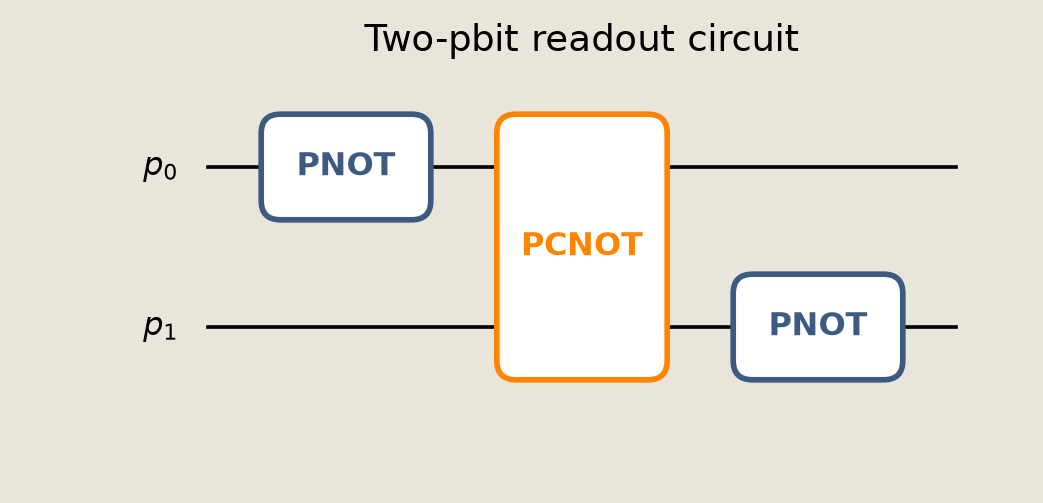

In [6]:
fig = P_sch.draw_pcircuit(
    circuit,
    wire_labels=[r"$p_0$", r"$p_1$"],
    title="Two-pbit readout circuit",
)
savefig(fig, "04_readout_circuit")

The circuit diagram shows the three gates applied to the two pbits in execution order. The single-pbit `PNOT` gates are drawn in slate, and the two-pbit `PCNOT` coupling gate is drawn in orange.

The `StateVectorSimulator` provides a reference distribution for the sampling estimates.

In [7]:
# Both inputs encode the |00) start. Derive the one-hot state-vector input from
# the bit pattern so the two simulator encodings cannot drift apart.
initial_bits = jnp.array([0, 0], dtype=jnp.int32)
start_index = int(initial_bits[0] * 2 + initial_bits[1])
initial_distribution = jnp.zeros(4).at[start_index].set(1.0)

exact_sim = StateVectorSimulator()
exact_compiled = exact_sim.build_circuit(circuit, thetas)
exact_density = np.asarray(exact_sim.density(exact_compiled, initial_distribution))
exact_expval = np.asarray(exact_sim.expval_all(exact_compiled, initial_distribution))

states = ["00", "01", "10", "11"]
print("exact density   p(s):", dict(zip(states, np.round(exact_density, 3).tolist())))
print("exact expval     <s>:", np.round(exact_expval, 3).tolist())

exact density   p(s): {'00': 0.4650000035762787, '01': 0.1550000011920929, '10': 0.15199999511241913, '11': 0.2280000001192093}
exact expval     <s>: [0.3799999952316284, 0.382999986410141]


The printed values give `exact_density` over basis states and the exact per-pbit expectation `exact_expval`. We score every sampled estimator below against these ground-truth references.

Sampling returns raw terminal bitstrings without computing statistics. For example, one call to `SampleSimulator.sample` draws 5,000 samples and returns a `(num_samples, num_pbits)` integer array.

In [8]:
NUM_SAMPLES = 5_000

sim = SampleSimulator(num_samples=NUM_SAMPLES)
sample_compiled = sim.build_circuit(circuit, thetas)
# Use a fixed PRNG key so the sampled readout is reproducible.
samples = np.asarray(sim.sample(sample_compiled, initial_bits, jax.random.key(SEED)))

assert samples.shape == (NUM_SAMPLES, 2)

print(f"samples shape: {samples.shape}  (num_samples, num_pbits)")
print(f"first five:    {samples[:5].tolist()}")

samples shape: (5000, 2)  (num_samples, num_pbits)
first five:    [[1, 1], [0, 0], [0, 1], [1, 0], [0, 0]]


The shape confirms that each row of `samples` is one sampled bitstring and each column is one pbit.

## Histogram and expectation

Both readouts are NumPy reductions of the `samples` array.

The histogram encodes each row as a basis-state index, counts with `np.bincount`, and divides by $N$. The per-pbit expectation is `samples.mean(axis=0)`.

Torx also exposes that second statistic directly as `SampleSimulator.expval_all`, which draws a fresh sample internally and returns the mean. At $N = 5{,}000$, both estimators land within `atol = 0.04` of the `StateVectorSimulator` reference.

In [9]:
# Histogram readout: reuse empirical_two_pbit_density to encode and count states.
sample_probs = empirical_two_pbit_density(samples)

sample_mean = samples.mean(axis=0)
# SEED + 1 is just a distinct PRNG key, so expval_all draws an independent
# sample rather than reusing the one above.
api_expval = np.asarray(
    sim.expval_all(sample_compiled, initial_bits, jax.random.key(SEED + 1))
)

print(
    f"sample probs    p_hat(s): {dict(zip(states, np.round(sample_probs, 3).tolist()))}"
)
print(f"sample mean   samples.mean: {np.round(sample_mean, 3).tolist()}")
print(f"expval_all (independent draw): {np.round(api_expval, 3).tolist()}")

sample probs    p_hat(s): {'00': 0.462, '01': 0.15, '10': 0.158, '11': 0.229}
sample mean   samples.mean: [0.388, 0.379]
expval_all (independent draw): [0.38600000739097595, 0.3970000147819519]


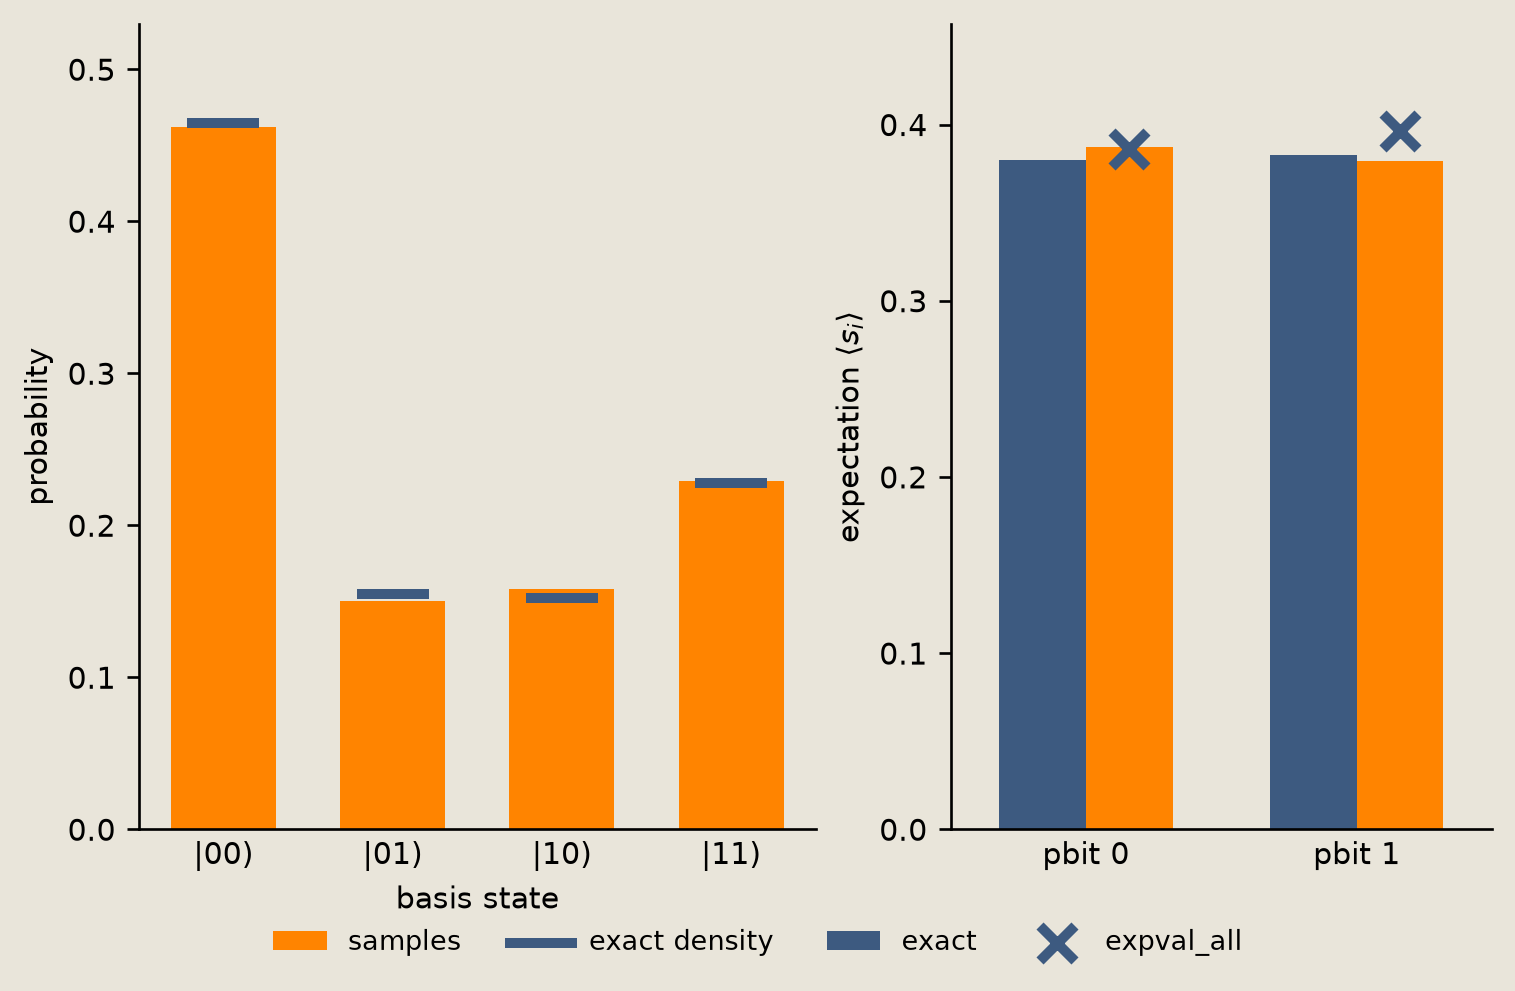

In [10]:
np.testing.assert_allclose(sample_probs.sum(), 1.0, atol=1e-6)
np.testing.assert_allclose(sample_probs, exact_density, atol=0.04)
np.testing.assert_allclose(sample_mean, exact_expval, atol=0.04)
np.testing.assert_allclose(api_expval, exact_expval, atol=0.04)

fig = P_samp.readout_histogram_expectation(
    sample_probs,
    exact_density,
    exact_expval,
    sample_mean,
    api_expval,
)
savefig(fig, "04_readout_histogram_expectation")

The sampled bars track `exact_density`. The `expval_all` cross lands close to both the `sample_mean` bar and the exact value, agreeing within Monte Carlo error even though it comes from an independent `SEED + 1` draw. This shows two routes to the same expectation.

## Histogram concentration

We draw the histogram at $N \in \{100, 500, 2000, 5000\}$.

The $N = 100$ panel is visibly jagged. By $N = 5000$, the bars sit on the exact density. Each panel reports the total-variation distance to `exact_density`, averaged over 16 non-overlapping blocks:

$$\overline{\mathrm{TV}}(\hat\rho, \rho) = \underbrace{\frac{1}{16} \sum_{k=1}^{16}}_{\vphantom{\big|}\text{block average}} \underbrace{\tfrac{1}{2} \sum_{s} |\hat\rho_k(s) - \rho(s)|}_{\vphantom{\big|}\text{TV per block}}.$$

The inner sum is the total-variation distance of one block $\hat\rho_k$ to the exact density $\rho$, and the outer factor averages it over the 16 blocks. That distance falls like $1/\sqrt{N}$, the convergence measured in the next figure.

In [11]:
PANEL_NS = [100, 500, 2_000, 5_000]
TV_REPLICATES = 16
LARGEST_N = max(PANEL_NS)

In [12]:
conv_sim = SampleSimulator(num_samples=LARGEST_N * TV_REPLICATES)
conv_compiled = conv_sim.build_circuit(circuit, thetas)
# Any key distinct from the draws above gives an independent convergence run.
conv_samples = np.asarray(
    conv_sim.sample(conv_compiled, initial_bits, jax.random.key(SEED + 100))
)

For each $N$ we form the empirical density and the block-averaged total-variation distance from this one run (the blocks at a given $N$ are disjoint, but the per-$N$ estimators reuse prefixes of the same run and are correlated across $N$).

In [13]:
np.testing.assert_array_equal(conv_samples.shape, (LARGEST_N * TV_REPLICATES, 2))

panel_probs = []
tv_means = []
for n in PANEL_NS:
    # Prefixes give the histogram panels; equal-size blocks estimate TV variation.
    panel_probs.append(empirical_two_pbit_density(conv_samples[:n]))
    blocks = conv_samples[: TV_REPLICATES * n].reshape(TV_REPLICATES, n, 2)
    block_tvs = [
        0.5 * np.abs(empirical_two_pbit_density(b) - exact_density).sum()
        for b in blocks
    ]
    tv_means.append(float(np.mean(block_tvs)))



TV log-log slope: -0.480  (illustrates -0.5)


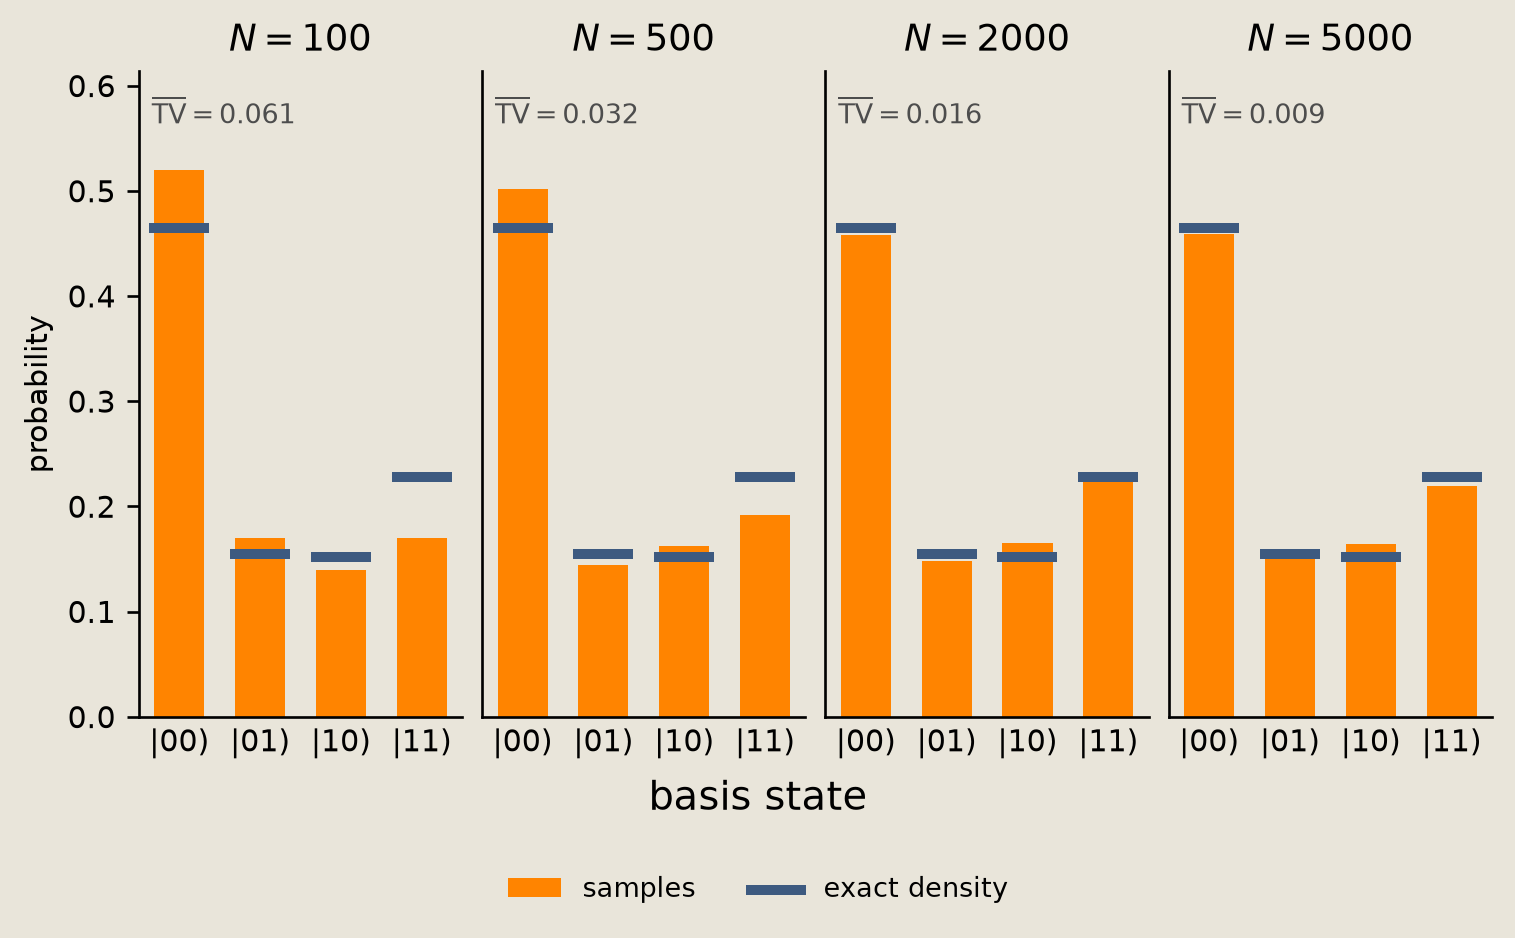

In [14]:
tv_means = np.asarray(tv_means)
# One finite run, so check the trend rather than pinning the exact rate:
# TV shrinks with N and the log-log slope sits in a band around -1/2.
tv_slope = float(np.polyfit(np.log(PANEL_NS), np.log(tv_means), 1)[0])
assert tv_means[-1] < tv_means[0]
assert -0.85 < tv_slope < -0.2
print(f"TV log-log slope: {tv_slope:.3f}  (illustrates -0.5)")

fig = P_samp.histogram_convergence(PANEL_NS, panel_probs, exact_density, tv_means)
savefig(fig, "04_histogram_convergence")

The bars tighten onto `exact_density` from left to right, and the per-panel total-variation distance decreases with $N$. A log-log least-squares fit of those distances has slope near $-1/2$ (printed above), consistent with the $1/\sqrt{N}$ Monte Carlo rate.

## Sample-mean concentration

Block analysis estimates how the `sample_mean` error scales with sample size.

A single estimate does not determine the error scaling, so we split one long run into many block estimators. We apply the block analysis to pbit 1:

1. draw one long $32{,}000$-sample run,
2. split it into non-overlapping blocks of size $N \in \{25, 50, 100, 200, 500, 1000\}$,
3. average pbit 1 within each block to form one estimator of $\langle s_1 \rangle$.

The blocks for a single $N$ are disjoint, but every per-$N$ estimator reuses a prefix of the same long run, so estimators across $N$ share samples and are correlated. That is fine for visualizing the slope, but it is not a set of independent cross-$N$ runs.

With 32 blocks per $N$, the analysis reports the mean absolute error; the shaded band is the standard error of that mean across the 32 blocks, not the raw block spread. The $N^{-1/2}$ reference is the central limit theorem (CLT) slope on a log-log plot.

In [15]:
BLOCK_SAMPLES = 32_000
NS = np.array([25, 50, 100, 200, 500, 1000])
REPLICATES = 32

The next cell draws the long `big_samples` run used for every block size.

In [16]:
big_sim = SampleSimulator(num_samples=BLOCK_SAMPLES)
big_compiled = big_sim.build_circuit(circuit, thetas)
# SEED + 2 is another distinct key, giving the long run its own draw.
big_samples = np.asarray(
    big_sim.sample(big_compiled, initial_bits, jax.random.key(SEED + 2))
)

In [17]:
readout = big_samples[:, 1]

block_means = np.stack(
    [readout[: REPLICATES * n].reshape(REPLICATES, n).mean(axis=1) for n in NS]
)
# Compare each block estimate with the exact pbit-1 expectation.
errors = np.abs(block_means - exact_expval[1])
err_mean = errors.mean(axis=1)
err_std = errors.std(axis=1, ddof=1)



sample-mean error log-log slope: -0.459  (illustrates -0.5)


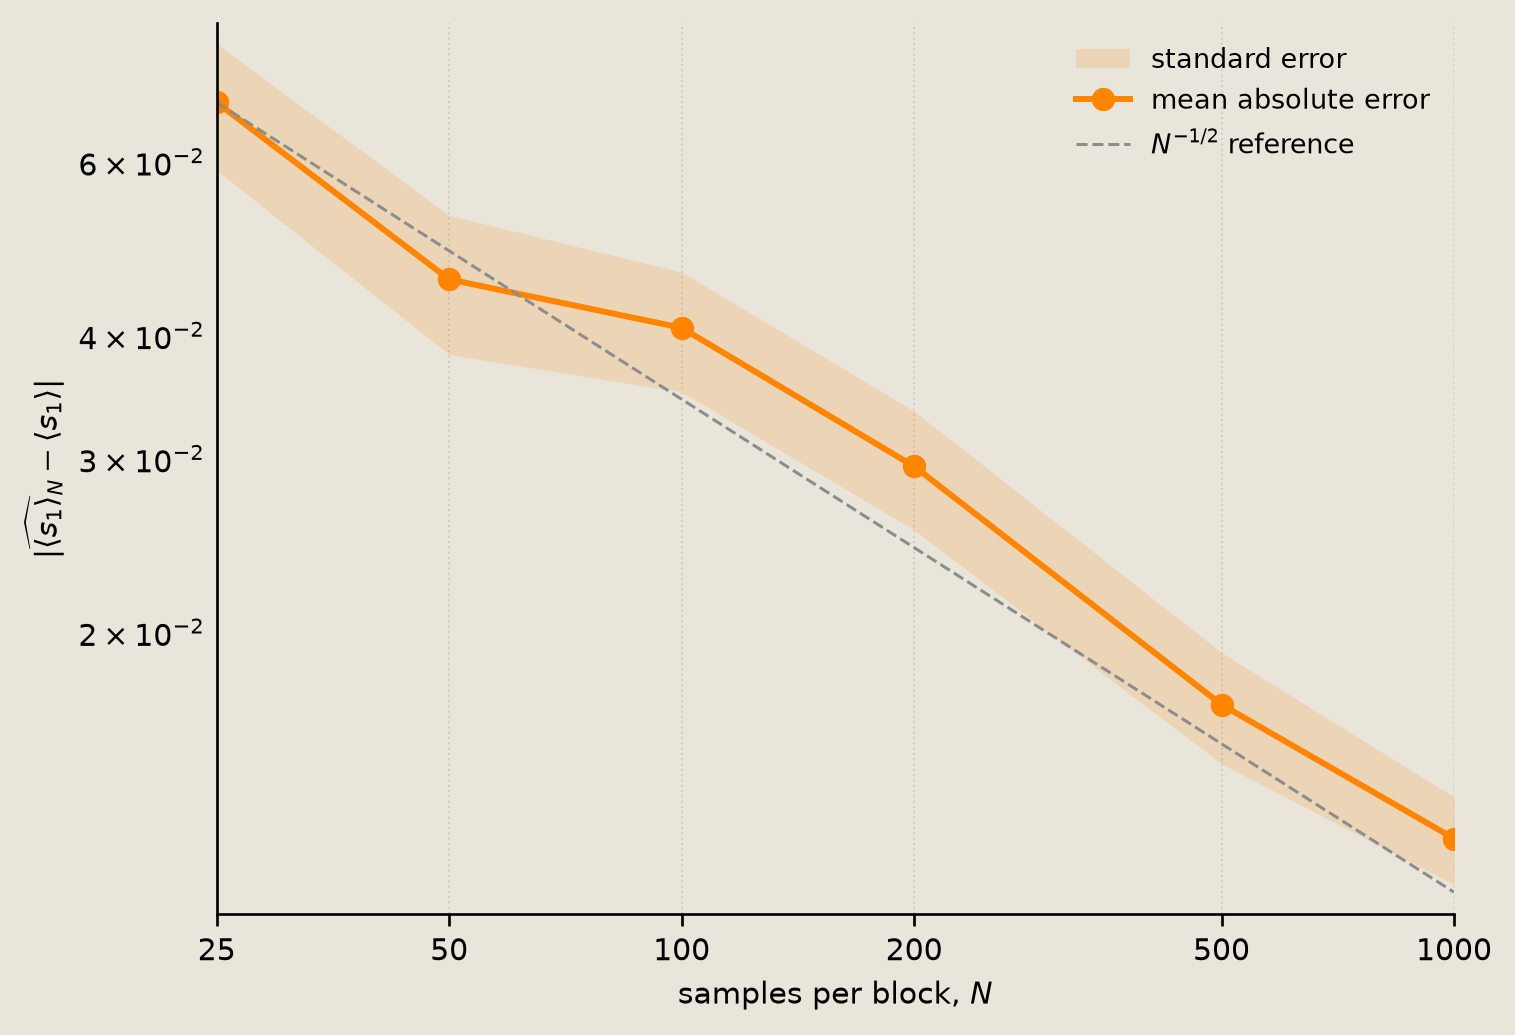

In [18]:
# One finite run with correlated prefixes, so check the trend, not the exact
# rate: the error shrinks with N and the log-log slope sits around -1/2.
err_slope = float(np.polyfit(np.log(NS), np.log(err_mean), 1)[0])
assert err_mean[-1] < err_mean[0]
assert -0.85 < err_slope < -0.2
print(f"sample-mean error log-log slope: {err_slope:.3f}  (illustrates -0.5)")

fig = P_samp.sample_mean_error(NS, err_mean, err_std, REPLICATES)
savefig(fig, "04_readout_clt_error")

The log-log curve follows the $N^{-1/2}$ reference for the pbit-1 readout error, and the least-squares slope above is close to $-1/2$, consistent with the Monte Carlo rate. The reference line is pinned at the smallest-$N$ point, so the demonstration is that the remaining points fall along it, not that the first point agrees by construction.

## Conclusion

This tutorial turned a Torx circuit's `samples` into densities, expectations, and a measured convergence rate.

- `SampleSimulator.sample` returns a `(num_samples, num_pbits)` integer array, and that array is the full stochastic output.
- `np.bincount` over the bitstrings approximates the exact `StateVectorSimulator` density to within sampling error (`atol = 0.04` at $N = 5000$). Separately, `samples.mean(axis=0)` and the independent `expval_all` draw are two estimators of the same expectation, both landing within that tolerance of the exact value.
- The sampling error shrinks as $1/\sqrt{N}$: a log-log fit of the block analysis on pbit 1 gives a slope near the $N^{-1/2}$ reference, consistent with the Monte Carlo rate.
- The terminal bitstring readouts shown here are ordinary NumPy reductions on the returned `samples` array. Differentiable or `jit`-transformable readouts use `jnp` or the Torx expectation APIs instead.

See also:

- [`05_chemical_reaction_networks.ipynb`](05_chemical_reaction_networks.ipynb), which uses `SampleSimulator` to recover a full trajectory against an exact reference.